# 特征值与奇异值分解实验

## 目标
手算矩阵 B 的特征分解；把它扩为三通道 A，核验 SVD、符号自由度、重复值子空间、低秩误差与条件数。

已核验的核心结果：B 的特征值为 1、3；A 的奇异值为 3、√3；秩1平方误差为3，保留率为3/4。合成图的已知非零奇异值为16、8、4、2、0.5、0.25，秩1只保留常量背景却有约75.22%的平方和。

## 准备
将本 Notebook、experiment.py 和 data 文件夹放在一起。Python 3.12、NumPy 2.3.5、Matplotlib 与 Jupyter/IPython 足够；不用网络、随机抽样或付费API。先读 lab.md，再选择重启内核并运行全部单元。

数学适用范围：实对称谱分解与一般实矩阵SVD；能量指元素平方和；截断最优性只针对完整矩阵的无权Frobenius或谱范数。有限数值检查不能代替一般证明。

In [1]:
# 第一步只检查环境与文件，不打印你的完整文件路径。
from pathlib import Path
import sys
import io
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
import experiment as e

np.set_printoptions(precision=8, suppress=True)
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("必需文件存在:", all(Path(f).exists() for f in [
    "experiment.py", "data/main_matrix.csv", "data/synthetic_field.csv"]))

def show_figure(fig):
    # 将图保存到内存并显示；不依赖浏览器外部图片地址。
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

Python: 3.12.14
NumPy: 2.3.5
必需文件存在: True


## 1 从数据到手算
A 的行是三个输出通道，不是三次独立抽样。先在纸上求 B 的特征值，再计算 A.T @ A。

In [2]:
B = np.array([[2., 1.], [1., 2.]])
A = np.loadtxt("data/main_matrix.csv", delimiter=",", skiprows=1)
print("B =", B, sep="\n")
print("A =", A, sep="\n")
print("A.T @ A =", A.T @ A, sep="\n")
print("精确有理数核验:", e.exact_hand_check())

B =
[[2. 1.]
 [1. 2.]]
A =
[[ 2.  1.]
 [ 1.  2.]
 [ 1. -1.]]
A.T @ A =
[[6. 3.]
 [3. 6.]]
精确有理数核验: {'B_eigenvalues': [1, 3], 'A_gram': [[6, 3], [3, 6]], 'A_singular_values': ['3', 'sqrt(3)'], 'rank1_frobenius_squared': '3', 'total_frobenius_squared': '12', 'rank1_energy_fraction': '3/4'}


## 2 核验特征方程与谱分解
`eigh` 按升序给出特征值，向量按列对应。符号可能与手算不同。这里使用公开的绝对和相对容差各1e-11。

In [3]:
eigenvalues, Q = e.symmetric_eigh(B)
print("特征值（升序）:", eigenvalues)
print("特征向量（各列）:", Q, sep="\n")
print("特征方程残差:", np.linalg.norm(B @ Q - Q * eigenvalues, ord="fro"))
print("重构残差:", np.linalg.norm(B - (Q * eigenvalues) @ Q.T, ord="fro"))
assert np.allclose(Q.T @ Q, np.eye(2), atol=e.ATOL, rtol=e.RTOL)
try:
    e.symmetric_eigh([[1, 2], [0, 1]])
except ValueError as error:
    print("预期拒绝非对称输入:", str(error))
print("正定性与非唯一性检查:", e.definiteness_and_uniqueness_checks())

特征值（升序）: [1. 3.]
特征向量（各列）:
[[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]
特征方程残差: 0.0
重构残差: 6.473657049138938e-16
预期拒绝非对称输入: 需要实对称输入
正定性与非唯一性检查: {'eigenvalues': {'positive_definite': [1.0, 3.0], 'semidefinite_not_definite': [0.0, 3.0], 'positive_entries_indefinite': [-1.0, 3.0]}, 'repeated_rank1_two_frobenius_errors': [2.0, 2.0], 'distinct_values_spectral_errors': [1.0, 1.0, 1.0], 'shear_eigenspace_dimension': 1}


## 3 完整与薄分解
完整 U 为3×3；薄 U 为3×2。s始终是长度2的一维数组。Vt已经是转置后的右向量矩阵。

In [4]:
U_full, s_full, Vt_full = np.linalg.svd(A, full_matrices=True)
U, s, Vt = np.linalg.svd(A, full_matrices=False)
Sigma_full = np.zeros(A.shape)
Sigma_full[:2, :2] = np.diag(s_full)
print("完整尺寸:", U_full.shape, Sigma_full.shape, Vt_full.shape)
print("薄尺寸:", U.shape, np.diag(s).shape, Vt.shape)
print("奇异值:", s)
print("完整重构误差:", np.linalg.norm(A - U_full @ Sigma_full @ Vt_full, ord="fro"))
print("薄重构误差:", np.linalg.norm(A - (U * s) @ Vt, ord="fro"))
assert np.allclose(U.T @ U, np.eye(2), atol=e.ATOL, rtol=e.RTOL)
assert np.allclose(Vt @ Vt.T, np.eye(2), atol=e.ATOL, rtol=e.RTOL)

完整尺寸: (3, 3) (3, 2) (2, 2)
薄尺寸: (3, 2) (2, 2) (2, 2)
奇异值: [3.         1.73205081]
完整重构误差: 6.080941944488118e-16
薄重构误差: 6.080941944488118e-16


## 4 成对翻号与单侧翻号
先预测哪一种保留 A，再运行。只翻第一层的一侧时，预期 Frobenius 距离为6。

In [5]:
U_flip, Vt_flip = U.copy(), Vt.copy()
U_flip[:, 0] *= -1
Vt_flip[0, :] *= -1
paired = (U_flip * s) @ Vt_flip
one_sided = (U_flip * s) @ Vt
print("成对翻号的重构误差:", np.linalg.norm(A - paired, ord="fro"))
print("只翻左侧的重构误差:", np.linalg.norm(A - one_sided, ord="fro"))
assert np.allclose(paired, A, atol=e.ATOL, rtol=e.RTOL)
assert not np.allclose(one_sided, A, atol=e.ATOL, rtol=e.RTOL)

成对翻号的重构误差: 6.080941944488118e-16
只翻左侧的重构误差: 5.999999999999999


## 5 重复奇异值应比较子空间
D的前两个奇异值相等。选一套新正交基，左右同时变换，重构和子空间投影不变。这里是有意构造替代分解，不依赖库是否恰好选择同一基。

In [6]:
D = np.diag([2., 2., 0.5])
angle = np.pi / 5
R = np.array([[np.cos(angle), -np.sin(angle)],
              [np.sin(angle), np.cos(angle)]])
H = np.eye(3)
H[:2, :2] = R
old_basis = np.eye(3)[:, :2]
new_basis = H[:, :2]
print("单根向量相同:", np.allclose(old_basis, new_basis))
print("同一矩阵作用:", np.allclose(H @ D @ H.T, D, atol=e.ATOL, rtol=e.RTOL))
print("投影之差:", np.linalg.norm(old_basis @ old_basis.T - new_basis @ new_basis.T, ord="fro"))

单根向量相同: False
同一矩阵作用: True
投影之差: 1.790389629463356e-17


## 6 主例逐层截断
k=0是零矩阵；k=1误差平方为3；k=2完整重构。`frobenius_actual` 是范数，不是平方和。

In [7]:
for k in range(3):
    approximation, info = e.truncated_svd(A, k)
    print("k =", k, "重构矩阵:", approximation, sep="\n")
    print("F误差/理论:", info["frobenius_actual"], info["frobenius_expected"])
    print("谱误差/理论:", info["spectral_actual"], info["spectral_expected"])
    print("保留率:", info["energy_fraction"])
zero_approximation, zero_info = e.truncated_svd(np.zeros((3, 2)), 0)
print("零矩阵能量比未定义:", zero_info["energy_fraction"] is None)

k =
0
重构矩阵:
[[0. 0.]
 [0. 0.]
 [0. 0.]]
F误差/理论: 3.4641016151377544 3.4641016151377544
谱误差/理论: 3.0 3.0
保留率: 0.0
k =
1
重构矩阵:
[[ 1.50000000e+00  1.50000000e+00]
 [ 1.50000000e+00  1.50000000e+00]
 [-4.50823842e-16 -4.50823842e-16]]
F误差/理论: 1.7320508075688774 1.7320508075688774
谱误差/理论: 1.7320508075688772 1.7320508075688774
保留率: 0.75
k =
2
重构矩阵:
[[ 2.  1.]
 [ 1.  2.]
 [ 1. -1.]]
F误差/理论: 6.080941944488118e-16 0.0
谱误差/理论: 5.993367621823974e-16 0.0
保留率: 1.0
零矩阵能量比未定义: True


## 7 合成强度场
32×32数据由一层常量背景与五层正交条纹生成。六个非零奇异值预先已知。所有图使用固定0到1的色标；秩1图不含条纹，却保留约75.22%的平方和。图中的英文 `energy` 只表示本实验的平方和比例。

数据尺寸: (32, 32)
已知奇异值: [16.    8.    4.    2.    0.5   0.25]
前6个实测奇异值: [16.    8.    4.    2.    0.5   0.25]
剩余最大数值: 1.2097076675905602e-15


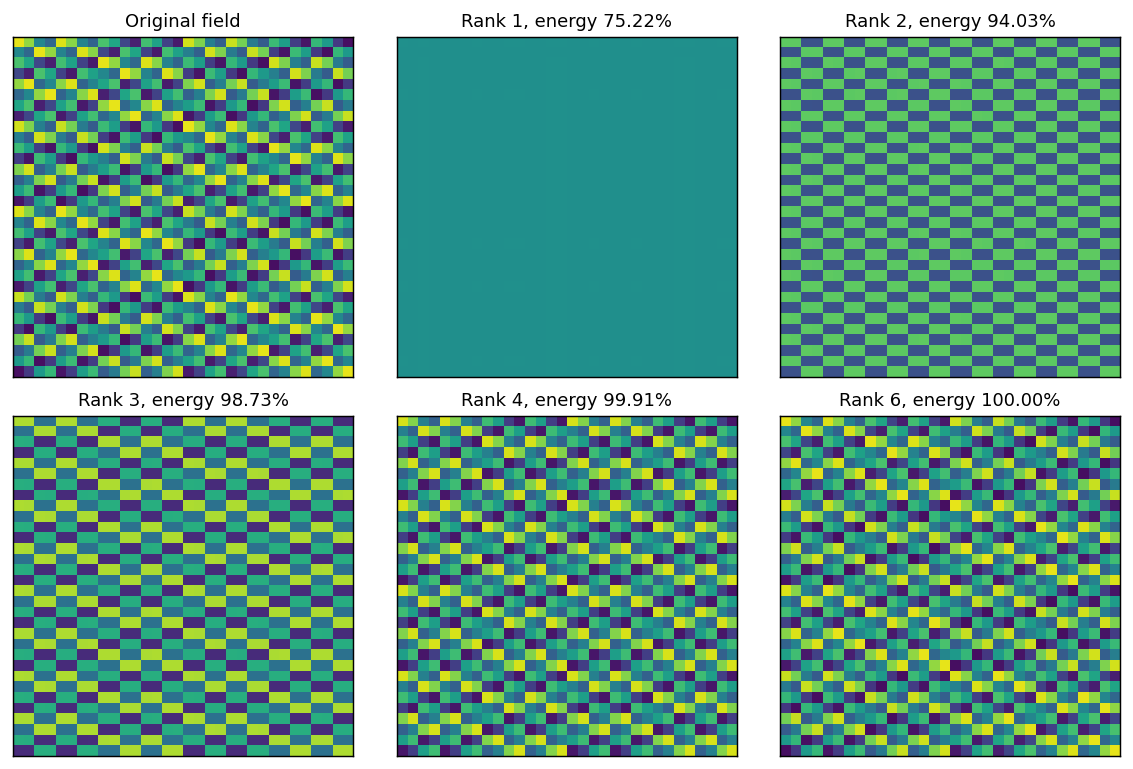

In [8]:
field = np.loadtxt("data/synthetic_field.csv", delimiter=",")
known_field, known_s = e.synthetic_field()
assert np.array_equal(field, known_field)
measured_s = np.linalg.svd(field, compute_uv=False)
print("数据尺寸:", field.shape)
print("已知奇异值:", known_s)
print("前6个实测奇异值:", measured_s[:6])
print("剩余最大数值:", np.max(measured_s[6:]))
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, k in zip(axes.flat, [None, 1, 2, 3, 4, 6]):
    if k is None:
        values, label = field, "Original field"
    else:
        values, info = e.truncated_svd(field, k)
        label = f"Rank {k}, energy {100 * info['energy_fraction']:.2f}%"
    ax.imshow(values, cmap="viridis", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(label, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
show_figure(fig)

## 8 误差公式与数值重构对应
实线为理论误差，散点为从实际重构矩阵计算的误差。完全重构附近的约1e-14误差是本次浮点运算的尺度，不是额外发现的信号。

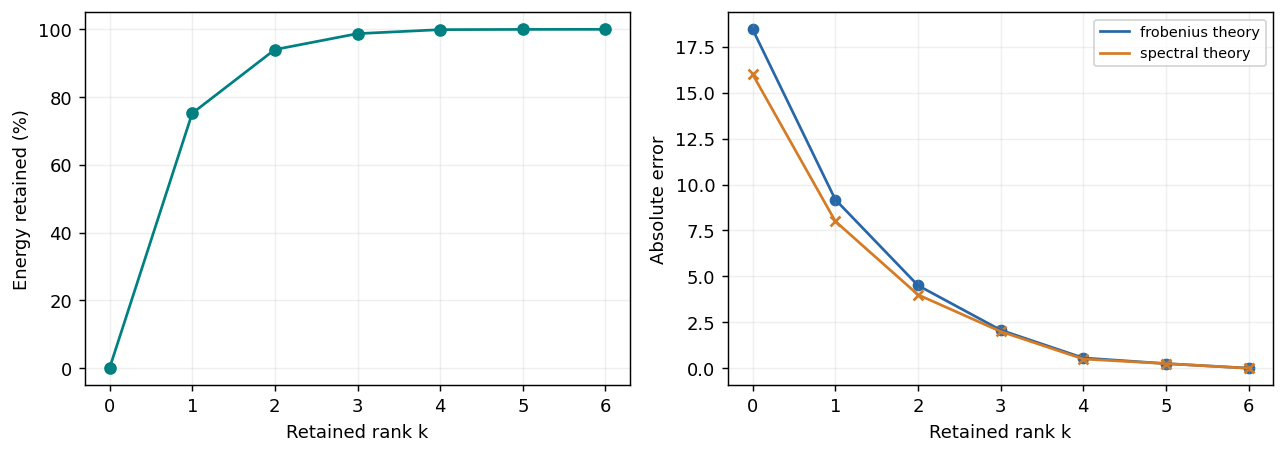

k=0: energy=0.00000000, F-error=18.447561
k=1: energy=0.75224977, F-error=9.1821838
k=2: energy=0.94031221, F-error=4.5069391
k=3: energy=0.98732782, F-error=2.076656
k=4: energy=0.99908173, F-error=0.55901699
k=5: energy=0.99981635, F-error=0.25
k=6: energy=1.00000000, F-error=9.5474263e-15


In [9]:
curves = [e.truncated_svd(field, k)[1] for k in range(7)]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
ks = np.arange(7)
axes[0].plot(ks, [100*c["energy_fraction"] for c in curves], "o-", color="teal")
axes[0].set_xlabel("Retained rank k"); axes[0].set_ylabel("Energy retained (%)")
for name, color, marker in [("frobenius", "#2867A7", "o"), ("spectral", "#D67B24", "x")]:
    axes[1].plot(ks, [c[name+"_expected"] for c in curves], color=color, label=name+" theory")
    axes[1].scatter(ks, [c[name+"_actual"] for c in curves], color=color, marker=marker, s=30)
axes[1].set_xlabel("Retained rank k"); axes[1].set_ylabel("Absolute error")
axes[1].legend(fontsize=8)
for ax in axes: ax.grid(alpha=.2)
fig.tight_layout(); show_figure(fig)
for c in curves:
    print(f"k={c['k']}: energy={c['energy_fraction']:.8f}, F-error={c['frobenius_actual']:.8g}")

## 9 条件数平方与 Gram 路线
对角矩阵精确显示平方条件数。另一组近共线矩阵比较直接 SVD 与先形成 Gram 再开平方；不把零或负值修成期望答案。

In [10]:
conditions = e.condition_checks()
for row in conditions["diagonal_cases"]:
    print("指数", row["exponent"], "cond", row["condition_2"], "Gram cond", row["gram_condition_2"])
for row in conditions["near_collinear_gram_audit"]:
    print("近共线指数", row["exponent"],
          "直接最小奇异值", row["direct_singular_values"][-1],
          "Gram 最小特征值", row["gram_eigenvalues"][0])
W = np.array([[1., 0., 0.], [0., 1., 0.]])
print("宽矩阵条件数:", np.linalg.cond(W))
print("非零输入被映成零:", W @ np.array([0., 0., 1.]))

指数 0 cond 1.0 Gram cond 1.0
指数 10 cond 1024.0 Gram cond 1048576.0
指数 20 cond 1048576.0 Gram cond 1099511627776.0
指数 30 cond 1073741824.0 Gram cond 1.152921504606847e+18
近共线指数 10 直接最小奇异值 0.0006905338836844195 Gram 最小特征值 4.768370445162873e-07
近共线指数 20 直接最小奇异值 6.743495761742278e-07 Gram 最小特征值 4.547473508864641e-13
近共线指数 26 直接最小奇异值 1.0536712127723509e-08 Gram 最小特征值 1.1102230246251565e-16
近共线指数 30 直接最小奇异值 6.585445079827193e-10 Gram 最小特征值 0.0
宽矩阵条件数: 1.0
非零输入被映成零: [0. 0.]


## 10 更换误差权重
下面输出两个秩1矩阵的加权与无权损失。100与9的比较否定的是“普通截断仍最优于这个加权问题”，不是否定无权Eckart–Young结论。

In [11]:
weighted = e.weighted_counterexample()
for name, value in weighted.items():
    print(name, value)
J = np.array([[0., -1.], [1., 0.]])
print("非对称旋转的特征值:", np.linalg.eig(J)[0])
print("同一个实矩阵的奇异值:", np.linalg.svd(J, compute_uv=False))

ordinary_rank1_weighted_loss 100.0
alternative_rank1_weighted_loss 9.0
ordinary_rank1_unweighted_loss 1.0
alternative_rank1_unweighted_loss 9.0
非对称旋转的特征值: [0.+1.j 0.-1.j]
同一个实矩阵的奇异值: [1. 1.]


## 11 边界与形状审计
27组边界包括输入资格、截断秩、方形/高形/宽形、秩亏、零、一阶、近奇异及无实特征值的情况。数值秩阈值公开记录。

In [12]:
boundary = e.boundary_checks()
print("通过组数:", boundary["passed_count"])
for row in boundary["shape_report"]:
    print(row["name"], "shape", row["shape"], "full U", row["full_U"],
          "reduced U", row["reduced_U"], "rank", row["numerical_rank"],
          "threshold", row["rank_absolute_tolerance"])
print("通过的边界名称:", boundary["names"])

通过组数: 27
square_full shape [2, 2] full U [2, 2] reduced U [2, 2] rank 2 threshold 1.3322676295501878e-15
tall_full shape [3, 2] full U [3, 3] reduced U [3, 2] rank 2 threshold 1.9984014443252818e-15
wide_full_row shape [2, 3] full U [2, 2] reduced U [2, 2] rank 2 threshold 6.661338147750939e-16
rank_deficient shape [3, 2] full U [3, 3] reduced U [3, 2] rank 1 threshold 3.3306690738754704e-15
zero shape [3, 2] full U [3, 3] reduced U [3, 2] rank 0 threshold 0.0
singleton shape [1, 1] full U [1, 1] reduced U [1, 1] rank 1 threshold 1.1102230246251565e-15
near_singular shape [2, 2] full U [2, 2] reduced U [2, 2] rank 2 threshold 4.440892098500626e-16
通过的边界名称: ['vector', 'empty', 'nan', 'infinity', 'complex', 'bool_array', 'bool_list', 'mixed_bool', 'string_array', 'mixed_string', 'object_array', 'object_leaf', 'not_square', 'not_symmetric', 'invalid_k_-1', 'invalid_k_3', 'invalid_k_0.5', 'invalid_k_True', 'square_full', 'tall_full', 'wide_full_row', 'rank_deficient', 'zero', 'singleton', 

## 12 汇总并保存
最后从数据读取到断言再运行一遍，并写入相对目录 outputs。观察有理数精确检查与浮点容差检查的区别。

In [13]:
report = e.run_all(write_outputs=True)
e.print_summary(report)
print("截断误差 CSV 存在:", Path("outputs/truncation_errors.csv").exists())

NumPy: 2.3.5
手算核对：B 特征值 [1, 3]；A 奇异值 [3, sqrt(3)]
A 的秩1误差平方：3；保留能量：3/4
重构 Frobenius 误差: 6.081e-16
合成图奇异值: [16.0, 8.0, 4.0, 2.0, 0.5, 0.25]
边界检查通过组数: 27
宽矩阵 cond=1，输入零空间维数仍为1
加权反例：普通截断损失100，另一个秩1矩阵损失9
输出文件存在: True
截断误差 CSV 存在: True


## 结论与复习
- 方向的符号或重复值块内基的变化可以合法；重构、正交与投影才是对应对象的检查。
- 低秩近似的最优性必须说明范数与观测方式。高能量保留率不等于高语义保留率。
- 宽矩阵的有限奇异值比不能保证参数唯一。形成 Gram 还可能丢失微弱方向。

请完成 lab.md 要求的一页实验记录，并对照 answers.md 中17道题。一般实对称谱定理作为明确前提，数值检查不取代一般证明。

验证范围：本 Notebook 已在新 Python 进程的真实进程内 IPython 内核中顺序执行，输出已保存。浏览器 Jupyter UI、外进程 socket 传输、学习者本机 Anaconda 安装没有测试。